In [124]:
import importlib
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import storage_model
importlib.reload(storage_model)
from storage_model import (
    Storage,
    run_valuation,
    curve_df_for_storage,
    quote_row_for_fd_date,
    active_masks,
    daily_arithmetic_flat_metric,
    smoothen_curve,
    monthly_curve_from_quote,
)

## Configuration
Edit the cells below to choose the curve source and product parameters, then run all cells.

In [125]:
# ── CURVE SOURCE ──────────────────────────────────────────────────────────────
# "ttf_excel" : reads from a TTF-style Excel file (quote_date + DA + TTFc1..N)
# "csv"       : reads from a CSV with columns contractStart, contractEnd, value
# "manual"    : define the curve inline as a list of dicts below
curve_source = "ttf_excel"

# -- ttf_excel settings -------------------------------------------------------
ttf_file = "ttf q.xlsx"          # path relative to this notebook
fd_date  = pd.Timestamp("2026-01-10")   # use the last available quote on or before this date

# -- csv settings -------------------------------------------------------------
csv_file = "curve.csv"           # must have columns: contractStart, contractEnd, value

# -- manual settings ----------------------------------------------------------
# Each row: {"contractStart": "YYYY-MM-DD", "contractEnd": "YYYY-MM-DD", "value": <float>}
manual_curve_rows = []

In [ ]:
# ── PRODUCT PARAMETERS ───────────────────────────────────────────────────────
product_type  = "call_swing"   # "put_swing" | "call_swing" | "storage"

val_date      = pd.Timestamp("2026-01-01")
storage_start = pd.Timestamp("2026-04-01")
storage_end   = pd.Timestamp("2027-03-30")

days          = 30     # exercise days / max capacity in clips (put_swing / call_swing)
vol           = 0.60   # daily spot vol
n_p_full      = 30     # price tree half-width
run_intrinsic = True   # set False to skip intrinsic build (faster, no decomposition)
v_step        = 1000   # MWh per clip

# Initial and terminal inventory in clips (1 clip = v_step MWh).
# None = product default: put_swing(init=0, term=days), call_swing(init=days, term=0), storage(init=0, term=0)
initial_inv_clips  = None
terminal_inv_clips = None

# call_swing only:
strike       = 0.0    # fixed exercise price (0 = exercise at forward; e.g. 40.0 for K=40 call)
zero_penalty = False  # True = unused clips carry no penalty at expiry (right, not obligation)

# storage-only
inj_days = 30
wdr_days = 30
inj_cost = 0.5
wdr_cost = 0.5

params = dict(
    product_type       = product_type,
    valDate            = val_date,
    storageStart       = storage_start,
    storageEnd         = storage_end,
    days               = days,
    vol                = vol,
    n_p_full           = n_p_full,
    run_intrinsic      = run_intrinsic,
    v_step             = v_step,
    initial_inv_clips  = initial_inv_clips,
    terminal_inv_clips = terminal_inv_clips,
    strike             = strike,
    zero_penalty       = zero_penalty,
    inj_days           = inj_days,
    wdr_days           = wdr_days,
    inj_cost           = inj_cost,
    wdr_cost           = wdr_cost,
)

## Load forward curve

In [127]:
def _load_ttf_excel(path, fd_date, val_date):
    """Load TTF-style Excel (quote_date + DA + TTFc1..N) and return a storage curve."""
    path = Path(path)
    if not path.exists():
        matches = sorted(Path.cwd().glob("*ttf*q*.xlsx"))
        if not matches:
            raise FileNotFoundError(f"Could not find {path}")
        path = matches[0]

    quotes = pd.read_excel(str(path))
    quotes = quotes.rename(columns={quotes.columns[0]: "quote_date"})
    quotes = quotes.dropna(subset=["quote_date"]).copy()
    quotes["quote_date"] = pd.to_datetime(quotes["quote_date"], format="mixed")
    quotes = quotes.sort_values("quote_date").reset_index(drop=True)

    contract_cols = sorted(
        [c for c in quotes.columns if re.fullmatch(r"TTFc\d+", str(c))],
        key=lambda c: int(re.search(r"\d+", str(c)).group()),
    )
    print(f"Loaded {len(quotes):,} quote dates, {len(contract_cols)} contracts from {path.name}")
    print(f"  Range: {quotes['quote_date'].min():%Y-%m-%d} to {quotes['quote_date'].max():%Y-%m-%d}")

    row = quote_row_for_fd_date(quotes, contract_cols, fd_date, exact=False)
    print(f"  FDDate requested: {pd.Timestamp(fd_date):%Y-%m-%d}  |  quote used: {row['quote_date']:%Y-%m-%d}")

    curve = curve_df_for_storage(row, contract_cols, curve_start=val_date, include_da=True)
    return curve, row


def _load_csv(path):
    """Load a CSV with columns contractStart, contractEnd, value."""
    df = pd.read_csv(path)
    df["contractStart"] = pd.to_datetime(df["contractStart"], format="mixed")
    df["contractEnd"]   = pd.to_datetime(df["contractEnd"],   format="mixed")
    df["value"]         = df["value"].astype(float)
    return df[["contractStart", "contractEnd", "value"]]


def _load_manual(rows):
    """Build a curve from a list of dicts with contractStart, contractEnd, value."""
    df = pd.DataFrame(rows)
    df["contractStart"] = pd.to_datetime(df["contractStart"])
    df["contractEnd"]   = pd.to_datetime(df["contractEnd"])
    df["value"]         = df["value"].astype(float)
    return df[["contractStart", "contractEnd", "value"]]


# ── load ──────────────────────────────────────────────────────────────────────
fd_quote_row = None

if curve_source == "ttf_excel":
    curve, fd_quote_row = _load_ttf_excel(ttf_file, fd_date, val_date)
elif curve_source == "csv":
    curve = _load_csv(csv_file)
elif curve_source == "manual":
    curve = _load_manual(manual_curve_rows)
else:
    raise ValueError(f"Unknown curve_source {curve_source!r}")

print(f"\nCurve covers: {curve['contractStart'].min():%Y-%m-%d} to {curve['contractEnd'].max():%Y-%m-%d}")
display(curve.head(6))

Loaded 4,171 quote dates, 55 contracts from ttf q.xlsx
  Range: 2010-03-12 to 2026-03-06
  FDDate requested: 2026-01-10  |  quote used: 2026-01-09

Curve covers: 2026-01-01 to 2030-08-31


,contractStart,contractEnd,value
0,2026-01-01,2026-01-31,29.000
1,2026-02-01,2026-02-28,28.374
2,2026-03-01,2026-03-31,27.899
3,2026-04-01,2026-04-30,26.971
4,2026-05-01,2026-05-31,26.479
5,2026-06-01,2026-06-30,26.439


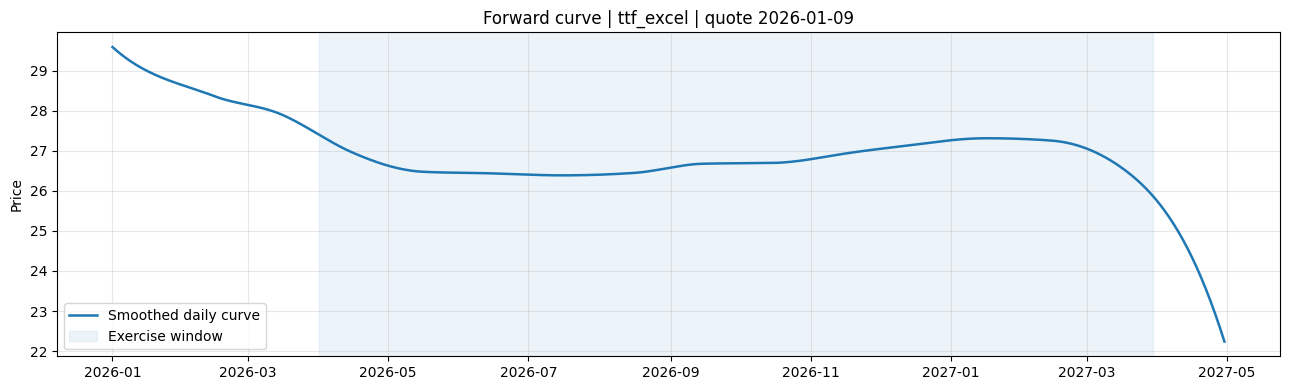

In [128]:
# ── Plot forward curve ────────────────────────────────────────────────────────
tmp = Storage(val_date, storage_start, storage_end, curve=curve, n_p=0, v_step=v_step, sVol=vol)
plot_curve = pd.Series(tmp.price_curve, index=tmp.date_span)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(plot_curve.index, plot_curve.values, linewidth=1.8, label="Smoothed daily curve")
ax.axvspan(storage_start, storage_end, alpha=0.08, color="tab:blue", label="Exercise window")
ax.set_title(f"Forward curve | {curve_source}" + (f" | quote {fd_quote_row['quote_date']:%Y-%m-%d}" if fd_quote_row is not None else ""))
ax.set_ylabel("Price")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Run valuation

In [129]:
print(f"Running {product_type} valuation...")
t0 = time.perf_counter()

s, result = run_valuation(curve, params)

print(f"Done in {time.perf_counter() - t0:.1f}s")

Running call_swing valuation...
Done in 0.3s


## Results

In [130]:
exercise_dates = s.date_span[s.Dt:s._active]
price_series   = pd.Series(s.price_curve, index=s.date_span)
arith_flat     = float(price_series.loc[exercise_dates].mean()) if product_type in ("put_swing", "call_swing") else np.nan

summary = pd.DataFrame([
    ("product_type",        product_type),
    ("val_date",            val_date.date()),
    ("storage_start",       storage_start.date()),
    ("storage_end",         storage_end.date()),
    ("flat_metric",         result["flat_metric"]),
    ("arith_flat_metric",   arith_flat),
    ("profiled_metric",     result["profiled_metric"]),
    ("intrinsic_value",     result["intrinsic"]),
    ("extrinsic_value",     result["extrinsic"]),
    ("total_value",         result["total"]),
], columns=["metric", "value"])

if product_type == "storage":
    summary = pd.concat([
        summary,
        pd.DataFrame([
            ("intrinsic_EUR", result.get("intrinsic_eur", np.nan)),
            ("extrinsic_EUR", result.get("extrinsic_eur", np.nan)),
            ("total_EUR",     result.get("total_eur",     np.nan)),
        ], columns=["metric", "value"]),
    ], ignore_index=True)

display(summary)

,metric,value
0,product_type,call_swing
1,val_date,2026-01-01
2,storage_start,2026-04-01
3,storage_end,2027-03-30
4,flat_metric,26.775035
5,arith_flat_metric,26.775035
6,profiled_metric,27.31519
7,intrinsic_value,0.540155
8,extrinsic_value,2.28987
9,total_value,2.830025


## Exercise profiles

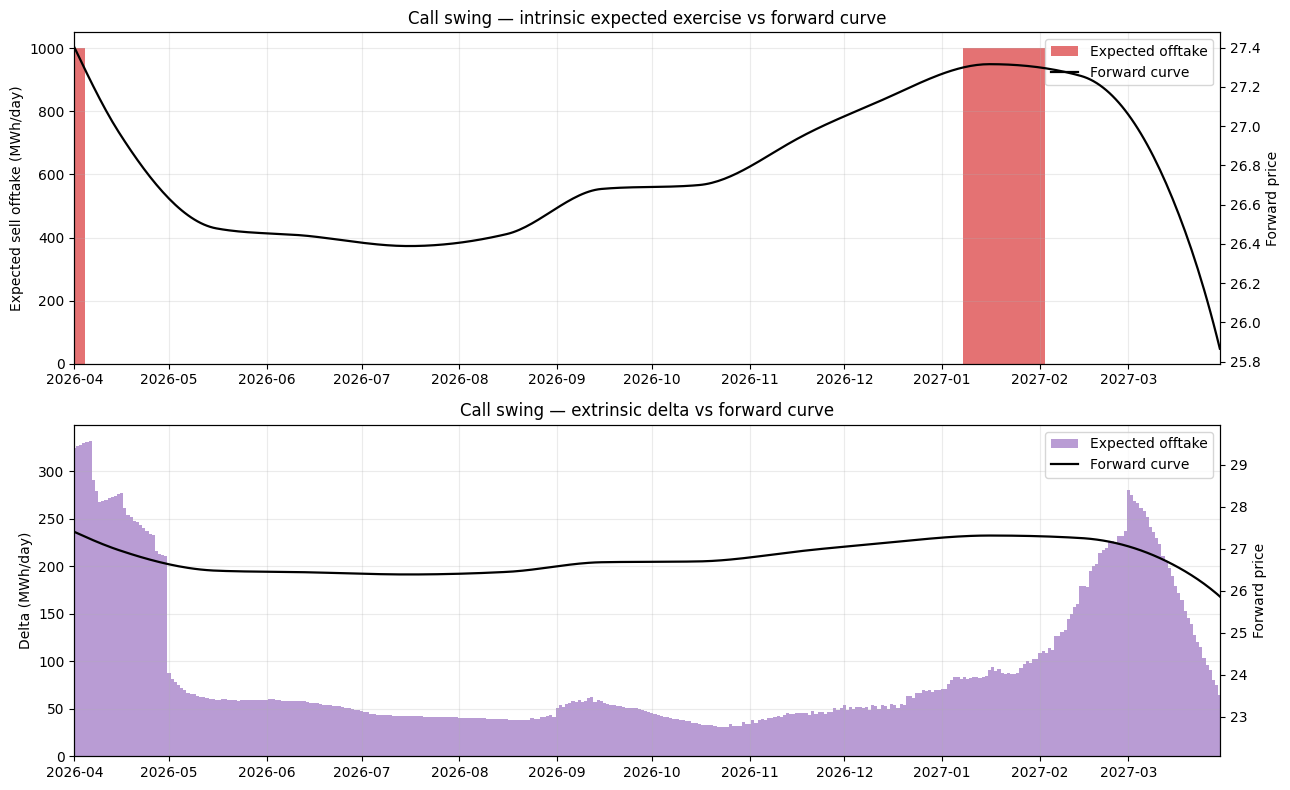

In [131]:
delta_dates = s.date_span[:s.n_t]
intrinsic_profile  = pd.Series(result["intrinsic_profile_raw"][:len(s.date_span)],  index=s.date_span).loc[exercise_dates]
extrinsic_delta    = pd.Series(np.array(s.delta[:s.n_t], dtype=float), index=delta_dates)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

for ax, profile, dates, title, color in [
    (axes[0], intrinsic_profile, exercise_dates,
     f"{result['title_prefix']} — intrinsic expected exercise vs forward curve", "tab:red"),
    (axes[1], extrinsic_delta,   delta_dates,
     f"{result['title_prefix']} — extrinsic delta vs forward curve", "tab:purple"),
]:
    ax_price = ax.twinx()
    if product_type == "storage":
        ax.bar(dates, np.where(profile.values > 0, profile.values, 0),
               width=1.0, color="tab:green", alpha=0.65, label="Sell / +delta")
        ax.bar(dates, np.where(profile.values < 0, profile.values, 0),
               width=1.0, color="tab:red",   alpha=0.65, label="Buy / -delta")
    else:
        ax.bar(dates, profile.values, width=1.0, color=color, alpha=0.65, label="Expected offtake")

    ax_price.plot(dates, price_series.loc[dates].values,
                  color="black", linewidth=1.6, label="Forward curve")
    ax.set_title(title)
    ax.set_ylabel(result["profile_label"] if ax is axes[0] else "Delta (MWh/day)")
    ax_price.set_ylabel("Forward price")
    ax.grid(True, alpha=0.25)
    ax.set_xlim(storage_start, storage_end)

    lines  = ax.get_legend_handles_labels()
    lines2 = ax_price.get_legend_handles_labels()
    ax.legend(lines[0] + lines2[0], lines[1] + lines2[1], loc="upper right")

plt.tight_layout()
plt.show()

## Monthly extrinsic deltas

In [132]:
monthly_delta = extrinsic_delta.loc[storage_start:storage_end].resample("MS").sum()
monthly_table = pd.DataFrame({
    "period": monthly_delta.index.strftime("%b-%y"),
    "delta":  monthly_delta.values,
})
monthly_table = pd.concat([
    monthly_table,
    pd.DataFrame([{"period": "Sum", "delta": monthly_table["delta"].sum()}]),
], ignore_index=True)

disp = monthly_table.copy()
disp["delta"] = disp["delta"].map("{:,.2f}".format)
display(disp)

,period,delta
0,Apr-26,"8,021.93"
1,May-26,"1,982.40"
2,Jun-26,"1,665.09"
3,Jul-26,"1,327.18"
4,Aug-26,"1,236.38"
5,Sep-26,"1,630.63"
6,Oct-26,"1,121.92"
7,Nov-26,"1,305.56"
8,Dec-26,"1,777.22"
9,Jan-27,"2,694.94"
